# SAM 3 fine-tuning with ANALYTICALLY estimated degradation

Pipeline:
1. **Analytically estimate** the noise/blur characteristics of the real degraded (Wilson)
   images from image statistics — no optimization loop
   (`synthetic_degradation.estimate_degradation_analytic`):
   - `sigma_psf` — max of multiscale variance-decay matching and edge-profile widths
     (each fails only toward under-estimation)
   - `contrast` — low-frequency std ratio (raw intensities)
   - `a, b` — least-squares fit of high-pass noise variance vs intensity, corrected for
     the filter's capture fraction
   - `sigma_r` — variance of noise row-means minus the white-noise share
   - `l, k` — log-linear fit of the radial noise autocorrelation (lag 1 skipped)
2. **Artificially degrade** the clean images with the estimated parameters (small per-image
   jitter for variety).
3. **Fine-tune** SAM 3's mask decoder on the degraded images paired with the **SAM-annotated
   masks** of the clean originals (the `sam3_mass_annotate.py` pseudo-labels; grains never move
   under blur/noise, so the masks stay valid). Same recipe as `SAM3_finetune.ipynb`:
   frozen encoder + cached embeddings, point prompts sampled per grain, 20·Focal+Dice+IoU loss,
   whole-image holdout with early stopping.

Estimation caveats (validated by recovery tests on synthetically degraded images): heavy blur
is under-estimated (~true 4 px → est ~2-3 px), `k` absorbs some grain texture, and cross-specimen
content differences bias `sigma_psf` — treat theta-hat as a calibrated starting point, refinable
with the BO loop in `surrogate_gp.py` if needed.

Run with the **`segmenteverygrain_new_SAM`** kernel; one SAM3 process at a time on 16 GB.

In [1]:
# ---------------- Config ----------------
CLEAN_REFERENCE = "testcleanimages"                    # clean set for the analytic comparison
BLURRY_GLOB = "alumina_training_data/cropped_Wilson180*_image.tif"   # real degraded references
PSEUDO_DIR = "testcleanimages_sam3_annotated/images_and_masks"       # SAM-annotated clean pairs
EXCLUDE_STEMS = ("099",)      # cropped_prac7_etched_099 is pixel-identical to the validation image
MAX_TRAIN_IMAGES = 24         # cap the embedding cache (16 GB machine)
THETA_JITTER = 0.2            # +-20% relative jitter of estimated theta per training image

VAL_STEMS = [                 # whole held-out images, same as all previous runs
    "cropped_Wilson180_0.25__surface1_12",   # real blurry (also excluded from BLURRY_GLOB below)
    "prac7_etched_099",                      # clean, hand-labelled GT
]

STEPS = 600
GRAINS_PER_STEP = 8
LR = 1e-4
VAL_EVERY = 50
PATIENCE = 4
MIN_GRAIN_SIZE = 25
SEED = 42

OUT_DECODER = "models/sam3_decoder_analytic_ft.pt" 

In [2]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import copy, glob, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from scipy import ndimage
from skimage.measure import label as connected_components
from transformers import Sam3TrackerModel, Sam3TrackerProcessor

from synthetic_degradation import (DegradationParams, THETA_NAMES,
                                   estimate_degradation_analytic,
                                   synthetic_degradation_model_input)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
rng = np.random.default_rng(SEED)

processor = Sam3TrackerProcessor.from_pretrained("facebook/sam3")
model = Sam3TrackerModel.from_pretrained("facebook/sam3").to(device)
for p in model.parameters():
    p.requires_grad_(False)
for p in model.mask_decoder.parameters():
    p.requires_grad_(True)
model.eval()
base_decoder_state = copy.deepcopy(model.mask_decoder.state_dict())

print(f"{device}: training "
      f"{sum(p.numel() for p in model.mask_decoder.parameters())/1e6:.1f}M of "
      f"{sum(p.numel() for p in model.parameters())/1e6:.0f}M params")

/Users/Alexander/miniforge3/envs/segmenteverygrain_new_SAM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] You are using a model of type `sam3_video` to instantiate a model of type `sam3_tracker`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 685/685 [00:00<00:00, 9209.98it/s]

mps: training 4.2M of 458M params


## 1. Analytic degradation estimate

Estimated from the real blurry Wilson training images (validation image excluded) against the
clean reference set, then previewed: clean | synthetically degraded with theta-hat | real blurry.

estimating from 4 blurry vs 8 clean reference images:


   sigma_psf = 3.3619
    contrast = 0.50088
           a = 0.0087247
           b = 0.00096688
     sigma_r = 0.0022264
           l = 0.81775
           k = 0.10197
  (sigma_psf estimates -- multiscale: 0.00, edge-profile: 3.36, spectral-ratio: 0.00; using max of first two)


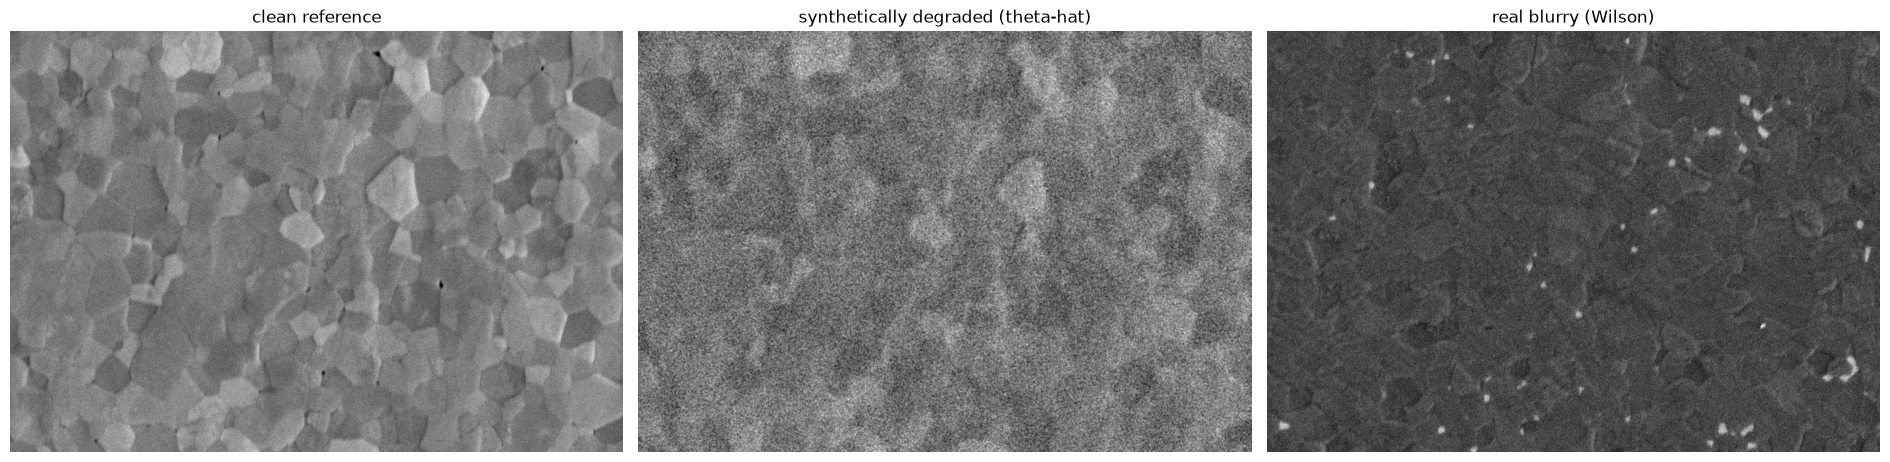

In [3]:
def load_gray(p):
    return np.asarray(Image.open(p).convert("L"), np.float32) / 255.0


clean_ref = [load_gray(p) for p in sorted(glob.glob(os.path.join(CLEAN_REFERENCE, "*.tif")))[:8]]
blurry_ref = [load_gray(p) for p in sorted(glob.glob(BLURRY_GLOB)) if "_12" not in p]
print(f"estimating from {len(blurry_ref)} blurry vs {len(clean_ref)} clean reference images:")
theta_hat, est_diag = estimate_degradation_analytic(clean_ref, blurry_ref)


def degrade_with(img_gray, params, rng):
    y = synthetic_degradation_model_input(img_gray, params, rng)
    return np.clip(y, 0.0, 1.0)


def jittered_theta(rng):
    vals = [getattr(theta_hat, n) * (1 + rng.uniform(-THETA_JITTER, THETA_JITTER))
            for n in THETA_NAMES]
    return DegradationParams(*vals)


fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].imshow(clean_ref[0], cmap="gray"); axes[0].set_title("clean reference")
axes[1].imshow(degrade_with(clean_ref[0], theta_hat, np.random.default_rng(0)), cmap="gray")
axes[1].set_title("synthetically degraded (theta-hat)")
axes[2].imshow(blurry_ref[0], cmap="gray"); axes[2].set_title("real blurry (Wilson)")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Data: SAM-annotated clean pairs, degraded

Training samples are (degraded clean image, SAM3 pseudo-label mask). Masks use
1=interior / 2=boundary / 3=ignore; only class-1 grains are ever sampled, so the ignore class
needs no special handling. The validation images are real (Wilson `_12`) and clean
(`prac7_etched_099`) hand-labelled images, untouched by the degradation.

In [4]:
def instances_from_mask(mask_fn, min_size=MIN_GRAIN_SIZE):
    m = np.array(Image.open(mask_fn))
    m = m[..., 0] if m.ndim == 3 else m
    inst = connected_components(m == 1, connectivity=1)
    sizes = np.bincount(inst.ravel())
    for i in np.where(sizes < min_size)[0]:
        inst[inst == i] = 0
    return connected_components(inst > 0, connectivity=1)


train_pairs = []
for img_fn in sorted(glob.glob(os.path.join(PSEUDO_DIR, "*_image.tif"))):
    stem = os.path.basename(img_fn).rsplit("_image", 1)[0]
    if any(x in stem for x in EXCLUDE_STEMS):
        continue
    mask_fn = img_fn.replace("_image.tif", "_mask.tif")
    if os.path.exists(mask_fn):
        train_pairs.append((stem, img_fn, mask_fn))
train_pairs = train_pairs[:MAX_TRAIN_IMAGES]

val_pairs = []
for stem in VAL_STEMS:
    for ext in (".tif", ".png"):
        img_fn = f"alumina_training_data/{stem}_image{ext}"
        if os.path.exists(img_fn):
            val_pairs.append((stem, img_fn, img_fn.replace("_image", "_mask")))
            break

print(f"train: {len(train_pairs)} pseudo-labelled clean images (to be degraded), "
      f"val: {len(val_pairs)}")
assert train_pairs and len(val_pairs) == len(VAL_STEMS)

train: 24 pseudo-labelled clean images (to be degraded), val: 2


## 3. Degrade + cache embeddings

Each training image is degraded once with a jittered theta-hat and embedded; random flips/rot90
are applied before degradation so orientation variety is free.

24 degraded training embeddings in 114s


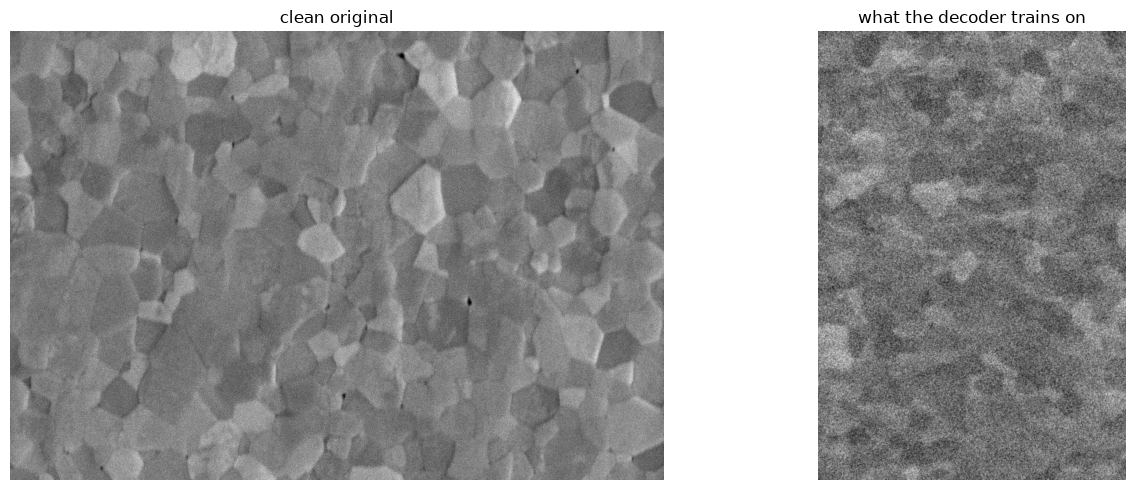

In [5]:
def to_device(obj, dev):
    if torch.is_tensor(obj):
        return obj.to(dev)
    if isinstance(obj, (list, tuple)):
        return type(obj)(to_device(o, dev) for o in obj)
    if isinstance(obj, dict):
        return {k: to_device(v, dev) for k, v in obj.items()}
    return obj


@torch.no_grad()
def embed(image_rgb):
    inputs = processor(images=image_rgb, return_tensors="pt").to(device)
    return to_device(model.get_image_embeddings(inputs["pixel_values"]), "cpu")


def random_geometry(image, inst, rng):
    k = int(rng.integers(0, 4))
    image, inst = np.rot90(image, k, (0, 1)), np.rot90(inst, k, (0, 1))
    if rng.random() < 0.5:
        image, inst = np.flip(image, 1), np.flip(inst, 1)
    return np.ascontiguousarray(image), np.ascontiguousarray(inst)


train_records, val_records = [], []
t0 = time.time()
for stem, img_fn, mask_fn in train_pairs:
    gray = load_gray(img_fn)
    inst = instances_from_mask(mask_fn)
    gray, inst = random_geometry(gray, inst, rng)
    degraded = degrade_with(gray, jittered_theta(rng), rng)
    rgb = np.stack([(degraded * 255).astype(np.uint8)] * 3, -1)
    train_records.append((embed(rgb), inst, rgb.shape[:2], stem))
print(f"{len(train_records)} degraded training embeddings in {time.time()-t0:.0f}s")

for stem, img_fn, mask_fn in val_pairs:
    image = np.array(Image.open(img_fn).convert("RGB"))
    val_records.append((embed(image), instances_from_mask(mask_fn), image.shape[:2], stem))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(load_gray(train_pairs[0][1]), cmap="gray"); axes[0].set_title("clean original")
gray0, inst0 = random_geometry(load_gray(train_pairs[0][1]), instances_from_mask(train_pairs[0][2]),
                               np.random.default_rng(1))
axes[1].imshow(degrade_with(gray0, jittered_theta(np.random.default_rng(1)),
                            np.random.default_rng(1)), cmap="gray")
axes[1].set_title("what the decoder trains on")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Prompted decoder forward, loss, and per-grain evaluation

In [6]:
def forward_grains(emb_cpu, points_list, labels_list, original_size, grad=True):
    """points_list: list of B (N, 2) float arrays (x, y). Returns logits (B, 1, H, W), iou (B,)."""
    inputs = processor(
        original_sizes=[list(original_size)],
        input_points=[[p.tolist() for p in points_list]],
        input_labels=[[list(l) for l in labels_list]],
        return_tensors="pt",
    ).to(device)
    with (torch.enable_grad() if grad else torch.no_grad()):
        out = model(image_embeddings=to_device(emb_cpu, device),
                    input_points=inputs["input_points"],
                    input_labels=inputs["input_labels"],
                    multimask_output=False)
        logits = F.interpolate(out.pred_masks[0], size=original_size,
                               mode="bilinear", align_corners=False)
    return logits, out.iou_scores.reshape(-1)


def losses(logits, gt, iou_pred):
    p = torch.sigmoid(logits)
    inter = (p * gt).sum((-2, -1))
    dice = 1 - (2 * inter + 1) / ((p + gt).sum((-2, -1)) + 1)
    bce = F.binary_cross_entropy_with_logits(logits, gt, reduction="none")
    pt = torch.exp(-bce)
    focal = (0.25 * (1 - pt) ** 2 * bce).mean((-2, -1))
    with torch.no_grad():
        hard = (logits > 0).float()
        iou_true = ((hard * gt).sum((-2, -1)) + 1) / (((hard + gt) > 0).float().sum((-2, -1)) + 1)
    return 20 * focal.mean() + dice.mean() + F.mse_loss(iou_pred, iou_true.reshape(-1))


def sample_interior(m, n, rng):
    core = ndimage.binary_erosion(m, iterations=3)
    ys, xs = np.where(core if core.any() else m)
    i = rng.integers(0, len(ys), n)
    return np.column_stack([xs[i], ys[i]]).astype(float)


def sample_ring(m, n, rng):
    ring = ndimage.binary_dilation(m, iterations=10) & ~m
    ys, xs = np.where(ring if ring.any() else ~m)
    i = rng.integers(0, len(ys), n)
    return np.column_stack([xs[i], ys[i]]).astype(float)


@torch.no_grad()
def per_grain_iou(emb_cpu, inst, original_size, chunk=16, max_grains=None):
    """Deterministic eval: one most-interior point per grain -> IoU vs GT."""
    ids = np.arange(1, inst.max() + 1)[:max_grains]
    ious = []
    for i in range(0, len(ids), chunk):
        pts, gts = [], []
        for gid in ids[i:i + chunk]:
            g = inst == gid
            d = ndimage.distance_transform_edt(g)
            y, x = np.unravel_index(np.argmax(d), d.shape)
            pts.append(np.array([[x, y]], float))
            gts.append(g)
        logits, _ = forward_grains(emb_cpu, pts, [[1]] * len(pts), original_size, grad=False)
        pred = (logits[:, 0] > 0).cpu().numpy()
        ious += [(p & g).sum() / max((p | g).sum(), 1) for p, g in zip(pred, gts)]
    return float(np.mean(ious))


def val_score():
    return {tag: per_grain_iou(emb, inst, osize) for emb, inst, osize, tag in val_records}

## 5. Train

Each step: pick a random (possibly augmented) image, sample `GRAINS_PER_STEP` grains, prompt with
1-2 interior points (+ a background point half the time), update the decoder. Early stopping on
mean validation per-grain IoU.

In [7]:
baseline = val_score()
print("baseline per-grain IoU:", {k: round(v, 3) for k, v in baseline.items()})

opt = torch.optim.AdamW(model.mask_decoder.parameters(), lr=LR, weight_decay=0.01)
history = {"step": [], "loss": [], "val_step": [], "val_iou": []}
best_iou, best_state, checks_since_best = float(np.mean(list(baseline.values()))), None, 0

t0 = time.time()
for step in range(1, STEPS + 1):
    emb, inst, osize, _ = train_records[rng.integers(0, len(train_records))]
    n = inst.max()
    ids = rng.choice(np.arange(1, n + 1), size=min(GRAINS_PER_STEP, n), replace=False)
    n_pos = int(rng.integers(1, 3))
    use_neg = rng.random() < 0.5
    pts, lbls, gts = [], [], []
    for gid in ids:
        g = inst == gid
        p, l = sample_interior(g, n_pos, rng), [1] * n_pos
        if use_neg:
            p = np.vstack([p, sample_ring(g, 1, rng)])
            l.append(0)
        pts.append(p); lbls.append(l); gts.append(g)

    logits, iou_pred = forward_grains(emb, pts, lbls, osize, grad=True)
    gt = torch.as_tensor(np.stack(gts), dtype=torch.float, device=device)[:, None]
    loss = losses(logits, gt, iou_pred)
    opt.zero_grad(); loss.backward(); opt.step()
    history["step"].append(step); history["loss"].append(loss.item())

    if step % VAL_EVERY == 0:
        scores = val_score()
        mean_iou = float(np.mean(list(scores.values())))
        history["val_step"].append(step); history["val_iou"].append(mean_iou)
        marker = ""
        if mean_iou > best_iou:
            best_iou, checks_since_best = mean_iou, 0
            best_state = copy.deepcopy(model.mask_decoder.state_dict())
            marker = "  <-- best"
        else:
            checks_since_best += 1
        print(f"step {step:4d}: loss {np.mean(history['loss'][-VAL_EVERY:]):.3f} | "
              f"val IoU {mean_iou:.3f} { {k: round(v, 3) for k, v in scores.items()} }{marker}",
              flush=True)
        if checks_since_best >= PATIENCE:
            print("early stop")
            break

print(f"done in {(time.time()-t0)/60:.1f} min; best val IoU {best_iou:.3f} "
      f"(baseline {np.mean(list(baseline.values())):.3f})")

baseline per-grain IoU: {'cropped_Wilson180_0.25__surface1_12': 0.686, 'prac7_etched_099': 0.629}


step   50: loss 0.397 | val IoU 0.670 {'cropped_Wilson180_0.25__surface1_12': 0.707, 'prac7_etched_099': 0.633}  <-- best


step  100: loss 0.385 | val IoU 0.687 {'cropped_Wilson180_0.25__surface1_12': 0.733, 'prac7_etched_099': 0.641}  <-- best


step  150: loss 0.374 | val IoU 0.676 {'cropped_Wilson180_0.25__surface1_12': 0.718, 'prac7_etched_099': 0.633}


step  200: loss 0.361 | val IoU 0.673 {'cropped_Wilson180_0.25__surface1_12': 0.712, 'prac7_etched_099': 0.634}


step  250: loss 0.368 | val IoU 0.686 {'cropped_Wilson180_0.25__surface1_12': 0.724, 'prac7_etched_099': 0.648}


step  300: loss 0.388 | val IoU 0.684 {'cropped_Wilson180_0.25__surface1_12': 0.728, 'prac7_etched_099': 0.641}


early stop
done in 3.0 min; best val IoU 0.687 (baseline 0.657)


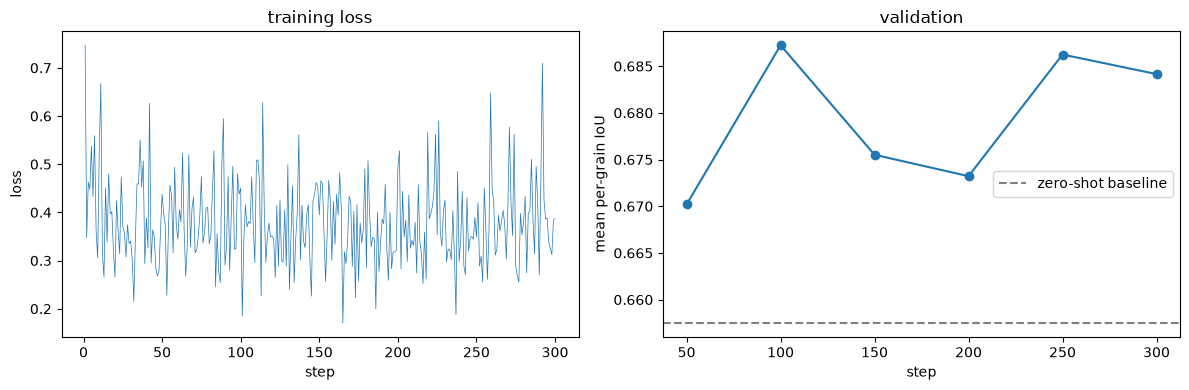

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["step"], history["loss"], lw=0.5)
axes[0].set(xlabel="step", ylabel="loss", title="training loss")
axes[1].plot(history["val_step"], history["val_iou"], "o-")
axes[1].axhline(np.mean(list(baseline.values())), ls="--", c="gray", label="zero-shot baseline")
axes[1].set(xlabel="step", ylabel="mean per-grain IoU", title="validation")
axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Save best decoder + before/after comparison

In [9]:
if best_state is not None:
    model.mask_decoder.load_state_dict(best_state)
os.makedirs(os.path.dirname(OUT_DECODER), exist_ok=True)
torch.save(model.mask_decoder.state_dict(), OUT_DECODER)
print(f"saved fine-tuned decoder -> {OUT_DECODER}")

final = val_score()
print(f"{'image':<45} {'zero-shot':>9} {'fine-tuned':>10}")
for k in final:
    print(f"{k:<45} {baseline[k]:>9.3f} {final[k]:>10.3f}")

saved fine-tuned decoder -> models/sam3_decoder_analytic_ft.pt


image                                         zero-shot fine-tuned
cropped_Wilson180_0.25__surface1_12               0.686      0.733
prac7_etched_099                                  0.629      0.641


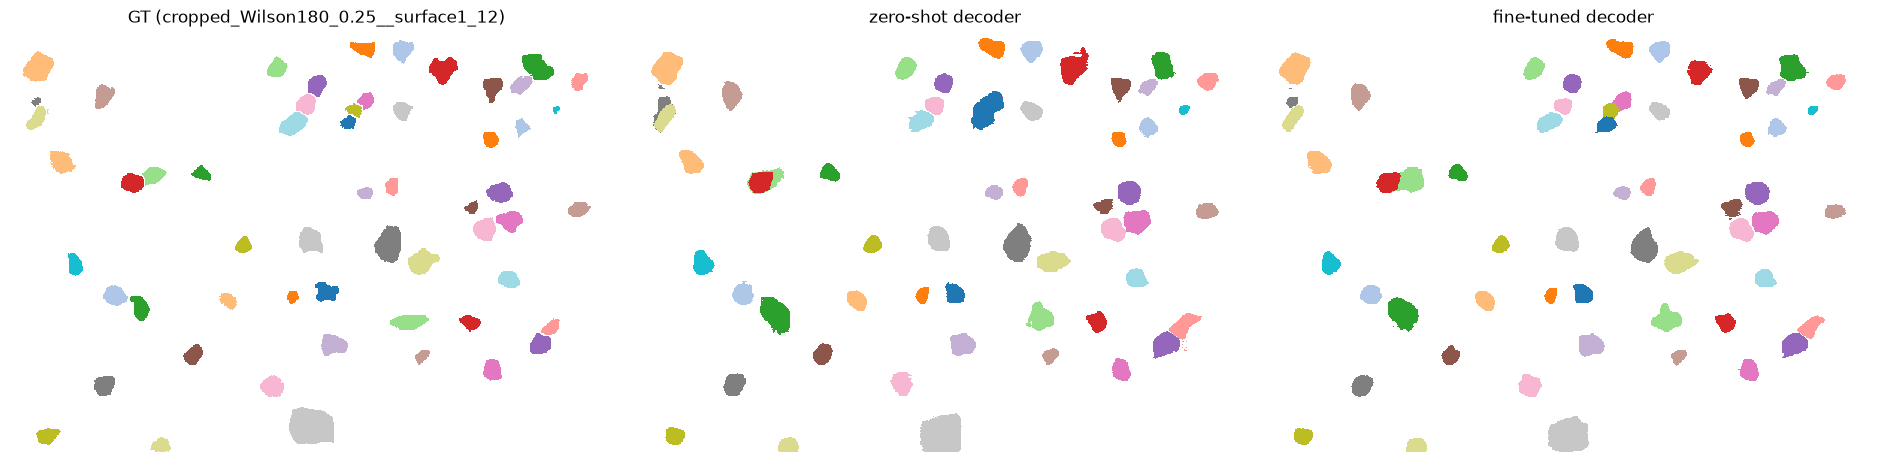

In [10]:
# Visual before/after on the first (blurry) validation image
emb, inst, osize, tag = val_records[0]
ids = np.arange(1, inst.max() + 1)

def render(state):
    model.mask_decoder.load_state_dict(state)
    out = np.zeros(osize, np.int32)
    for i in range(0, len(ids), 16):
        pts = []
        for gid in ids[i:i + 16]:
            d = ndimage.distance_transform_edt(inst == gid)
            y, x = np.unravel_index(np.argmax(d), d.shape)
            pts.append(np.array([[x, y]], float))
        logits, _ = forward_grains(emb, pts, [[1]] * len(pts), osize, grad=False)
        for j, gid in enumerate(ids[i:i + 16]):
            out[(logits[j, 0] > 0).cpu().numpy()] = gid
    return out

pred_base = render(base_decoder_state)
pred_ft = render(torch.load(OUT_DECODER, map_location=device))

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (m, title) in zip(axes, [(inst, f"GT ({tag})"), (pred_base, "zero-shot decoder"),
                                 (pred_ft, "fine-tuned decoder")]):
    ax.imshow(np.where(m > 0, m % 20, np.nan), cmap="tab20", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout(); plt.show()